## tune-year-weight.ipynb

Tunes `W_YEAR` for the V4 model using the same two-phase approach as
`tune-base-weights.ipynb`. All other weights are fixed at their best
values from `best_weights.json`.

Because `W_YEAR` is a single free weight, both phases are 1D:

| Phase | Approach | Combinations | Est. time |
|---|---|---|---|
| 1 | 20-point log-uniform scan over [0.1, 10.0] | 20 | ~10 min |
| 2 | 10-point fine grid centred on Phase 1 best | 10 | ~5 min |

**Pre-computation:** base + fixed blocks are pre-stored as float16 SEED_DOTS
(same as tune-base-weights.ipynb), plus the year block added on top.
Peak RAM: ~20 GB.

In [1]:
import os
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import load_npz, hstack, csr_matrix

DATA_DIR     = '../data'
FEATURES_DIR = f'{DATA_DIR}/features'
N_RESULTS    = 10
CHUNK_SIZE   = 50_000
K_TOP        = 30

# All weights fixed except W_YEAR
with open(f'{DATA_DIR}/best_weights.json') as f:
    best_weights = json.load(f)

FIXED = best_weights['v3']   # use V3 base-tuned weights as the fixed foundation
print('Fixed weights:')
for k, v in FIXED.items():
    print(f'  {k:<18} = {v}')

Fixed weights:
  W_TAGS             = 1.0
  W_LABELS           = 0.32472055144502865
  W_TYPES            = 3.5067764992972172
  W_RATINGS          = 0.1
  W_COUNTRY          = 1.0
  W_TRACK_STATS      = 0.25
  W_ROLE_FAMILY      = 0.05
  W_INSTRUMENT       = 0.03
  W_CONTRIB_CNT      = 0.0


In [2]:
try:
    lastfm = pd.read_parquet(f'{DATA_DIR}/lastfm_similar_albums.parquet')
except Exception:
    lastfm = pd.read_csv(f'{DATA_DIR}/lastfm_similar_albums.csv')

lastfm.columns = lastfm.columns.str.strip()
for col in ['album','artist','similar_album','similar_artist']:
    lastfm[col + '_key'] = lastfm[col].str.lower().str.strip()

mb_lookup = (
    pd.read_parquet(f'{DATA_DIR}/mb_album_artists.parquet',
                    columns=['album_id','album_name','artist_name'])
    .drop_duplicates(subset='album_id')
)
mb_lookup['album_key']  = mb_lookup['album_name'].str.lower().str.strip()
mb_lookup['artist_key'] = mb_lookup['artist_name'].str.lower().str.strip()
mb_index = mb_lookup.set_index(['album_key','artist_key'])['album_id']

seed_pairs = lastfm[['album_key','artist_key']].drop_duplicates()
seed_pairs = seed_pairs.join(mb_index.rename('seed_mb_id'),
                              on=['album_key','artist_key'], how='left')
lastfm = lastfm.join(mb_index.rename('similar_mb_id'),
                      on=['similar_album_key','similar_artist_key'], how='left')
lastfm = lastfm.merge(seed_pairs, on=['album_key','artist_key'], how='left')

ground_truth_raw = (
    lastfm.dropna(subset=['seed_mb_id','similar_mb_id'])
    .groupby('seed_mb_id')['similar_mb_id']
    .apply(set).to_dict()
)
ground_truth_raw = {int(k): {int(v) for v in vs}
                    for k, vs in ground_truth_raw.items()}
print(f'Ground truth (raw): {len(ground_truth_raw):,} seed albums')

Ground truth (raw): 2,421 seed albums


In [3]:
with open(f'{FEATURES_DIR}/album_ids.pkl', 'rb') as f:
    album_id_order = pickle.load(f)

X_tags        = load_npz(f'{FEATURES_DIR}/album_tags_matrix.npz')
X_labels      = load_npz(f'{FEATURES_DIR}/album_labels_matrix.npz')
X_types       = load_npz(f'{FEATURES_DIR}/album_types_matrix.npz')
X_ratings     = load_npz(f'{FEATURES_DIR}/album_ratings_matrix.npz')
X_country     = load_npz(f'{FEATURES_DIR}/album_country_matrix.npz')
X_track_stats = load_npz(f'{FEATURES_DIR}/album_track_stats_matrix.npz')
X_role_family = load_npz(f'{FEATURES_DIR}/album_role_family_matrix.npz')
X_instrument  = load_npz(f'{FEATURES_DIR}/album_instrument_matrix.npz')
X_contrib_cnt = load_npz(f'{FEATURES_DIR}/album_contributor_counts_matrix.npz')
X_year        = load_npz(f'{FEATURES_DIR}/album_year_matrix.npz')

# Expand to full album universe
full_album_ids = pd.Index(
    pd.read_parquet(f'{DATA_DIR}/mb_album.parquet', columns=['id'])['id'].sort_values()
)
if len(album_id_order) < len(full_album_ids):
    pos    = full_album_ids.get_indexer(album_id_order)
    n_full = len(full_album_ids)
    def _expand(X, row_pos, n):
        coo = X.tocoo()
        return csr_matrix((coo.data, (row_pos[coo.row], coo.col)),
                          shape=(n, X.shape[1]))
    X_tags        = _expand(X_tags,        pos, n_full)
    X_labels      = _expand(X_labels,      pos, n_full)
    X_types       = _expand(X_types,       pos, n_full)
    X_ratings     = _expand(X_ratings,     pos, n_full)
    X_country     = _expand(X_country,     pos, n_full)
    X_track_stats = _expand(X_track_stats, pos, n_full)
    X_role_family = _expand(X_role_family, pos, n_full)
    X_instrument  = _expand(X_instrument,  pos, n_full)
    X_contrib_cnt = _expand(X_contrib_cnt, pos, n_full)
    X_year        = _expand(X_year,        pos, n_full)
    album_id_order = full_album_ids.tolist()

print('Blocks loaded and expanded.')

Blocks loaded and expanded.


In [4]:
X_base_full   = hstack([X_tags, X_labels, X_types, X_ratings]).tocsr()
has_feat      = np.diff(X_base_full.indptr) > 0
ann_ids       = np.array(album_id_order)[has_feat]
id2row_ann    = {int(aid): i for i, aid in enumerate(ann_ids)}
n_ann         = int(has_feat.sum())
all_model_ids = set(int(x) for x in ann_ids)

def _clean(X):
    M = X[has_feat].tocsr().astype(np.float32)
    np.nan_to_num(M.data, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
    M.eliminate_zeros()
    return M

BLK = {
    'tags':        _clean(X_tags),
    'labels':      _clean(X_labels),
    'types':       _clean(X_types),
    'ratings':     _clean(X_ratings),
    'country':     _clean(X_country),
    'track_stats': _clean(X_track_stats),
    'role_family': _clean(X_role_family),
    'instrument':  _clean(X_instrument),
    'contrib_cnt': _clean(X_contrib_cnt),
    'year':        _clean(X_year),
}
BLK_ROW_SQ = {
    k: np.asarray(M.power(2).sum(axis=1)).ravel().astype(np.float32)
    for k, M in BLK.items()
}

# Scope-filter ground truth
ground_truth = {
    k: {v for v in vs if v in all_model_ids}
    for k, vs in ground_truth_raw.items()
}
ground_truth = {k: vs for k, vs in ground_truth.items()
                if k in id2row_ann and vs}
seed_ids   = list(ground_truth.keys())
seed_rows  = np.array([id2row_ann[s] for s in seed_ids], dtype=np.int32)
seed_known = [ground_truth[s] for s in seed_ids]
n_seeds    = len(seed_ids)
print(f'Annotated albums: {n_ann:,}')
print(f'Seeds in model index: {n_seeds:,}')
print(f'Year coverage in annotated set: '
      f'{BLK["year"].nnz:,} / {n_ann:,}  '
      f'({BLK["year"].nnz/n_ann*100:.1f}%)')

Annotated albums: 1,008,102
Seeds in model index: 1,974
Year coverage in annotated set: 997,497 / 1,008,102  (98.9%)


In [5]:
# ── Pre-compute SEED_DOTS ─────────────────────────────────────────────────
# Base blocks (searched in base tuning) + year block → float16
# Fixed blocks (V3 non-base weights) → summed into FIXED_DOTS once
#
# Memory: (4 base + 1 year) × ~4 GB float16 = ~20 GB
#         FIXED_DOTS float32 = ~8 GB
#         Total peak ≈ 28 GB  — tight on 32 GB, run after freeing other notebooks

BASE_BLOCKS  = ['tags', 'labels', 'types', 'ratings', 'year']
FIXED_BLOCKS = {
    'country':     FIXED.get('W_COUNTRY',     0.0),
    'track_stats': FIXED.get('W_TRACK_STATS', 0.0),
    'role_family': FIXED.get('W_ROLE_FAMILY', 0.0),
    'instrument':  FIXED.get('W_INSTRUMENT',  0.0),
    'contrib_cnt': FIXED.get('W_CONTRIB_CNT', 0.0),
}

print('Pre-computing base + year SEED_DOTS (float16)...')
t0 = time.time()
SEED_DOTS     = {}
SEED_NORMS_SQ = {}
for k in BASE_BLOCKS:
    M = BLK[k]
    Q = M[seed_rows]
    D = np.ascontiguousarray(M.dot(Q.T).toarray().T.astype(np.float16))
    SEED_DOTS[k]     = D
    SEED_NORMS_SQ[k] = BLK_ROW_SQ[k][seed_rows].astype(np.float32)
    print(f'  {k:<14} {str(D.shape):<22} {D.nbytes/1e9:.2f} GB  ({time.time()-t0:.0f}s)')

print('Pre-computing fixed block dot products (constant)...')
FIXED_DOTS     = np.zeros((n_seeds, n_ann), dtype=np.float32)
FIXED_NORMS_SQ = np.zeros(n_seeds, dtype=np.float32)
FIXED_CAND_SQ  = np.zeros(n_ann,   dtype=np.float32)
for k, w in FIXED_BLOCKS.items():
    if w == 0.0:
        continue
    w2 = np.float32(w ** 2)
    M  = BLK[k]
    Q  = M[seed_rows]
    D  = M.dot(Q.T).toarray().T.astype(np.float32)
    FIXED_DOTS     += w2 * D
    FIXED_NORMS_SQ += w2 * BLK_ROW_SQ[k][seed_rows]
    FIXED_CAND_SQ  += w2 * BLK_ROW_SQ[k]
    print(f'  {k:<14} w={w:.3f}  added')

print(f'\nDone in {time.time()-t0:.0f}s')

Pre-computing base + year SEED_DOTS (float16)...
  tags           (1974, 1008102)        3.98 GB  (34s)
  labels         (1974, 1008102)        3.98 GB  (61s)
  types          (1974, 1008102)        3.98 GB  (90s)
  ratings        (1974, 1008102)        3.98 GB  (116s)
  year           (1974, 1008102)        3.98 GB  (167s)
Pre-computing fixed block dot products (constant)...
  country        w=1.000  added
  track_stats    w=0.250  added
  role_family    w=0.050  added
  instrument     w=0.030  added

Done in 394s


In [6]:
def evaluate_weights(weights: dict, n: int = N_RESULTS) -> dict:
    w2 = {
        'tags':    np.float32(weights.get('W_TAGS',    1.0) ** 2),
        'labels':  np.float32(weights.get('W_LABELS',  FIXED['W_LABELS']) ** 2),
        'types':   np.float32(weights.get('W_TYPES',   FIXED['W_TYPES']) ** 2),
        'ratings': np.float32(weights.get('W_RATINGS', FIXED['W_RATINGS']) ** 2),
        'year':    np.float32(weights.get('W_YEAR',    0.0) ** 2),
    }

    cand_norm_sq = FIXED_CAND_SQ.copy()
    q_norm_sq    = FIXED_NORMS_SQ.copy()
    for k, w2k in w2.items():
        cand_norm_sq += w2k * BLK_ROW_SQ[k]
        q_norm_sq    += w2k * SEED_NORMS_SQ[k]
    cand_norms = np.sqrt(cand_norm_sq); cand_norms[cand_norms == 0] = 1.0
    q_norms    = np.sqrt(q_norm_sq);    q_norms[q_norms == 0]       = 1.0

    best_scores = np.full((n_seeds, K_TOP), -np.inf, dtype=np.float32)
    best_cols   = np.zeros((n_seeds, K_TOP), dtype=np.int32)
    chunk_buf   = np.empty((n_seeds, CHUNK_SIZE), dtype=np.float32)

    for col_start in range(0, n_ann, CHUNK_SIZE):
        col_end = min(col_start + CHUNK_SIZE, n_ann)
        csize   = col_end - col_start
        chunk   = chunk_buf[:, :csize]
        chunk[:] = FIXED_DOTS[:, col_start:col_end]
        for k, w2k in w2.items():
            chunk += w2k * SEED_DOTS[k][:, col_start:col_end].astype(np.float32)
        chunk /= q_norms[:, None]
        chunk /= cand_norms[None, col_start:col_end]
        self_mask = (seed_rows >= col_start) & (seed_rows < col_end)
        for s_idx in np.where(self_mask)[0]:
            chunk[s_idx, seed_rows[s_idx] - col_start] = -1.0
        k_use = min(K_TOP, csize)
        chunk_top_idx    = np.argpartition(chunk, -k_use, axis=1)[:, -k_use:]
        chunk_top_scores = chunk[np.arange(n_seeds)[:, None], chunk_top_idx]
        chunk_top_cols   = (chunk_top_idx + col_start).astype(np.int32)
        combined_scores  = np.concatenate([best_scores, chunk_top_scores], axis=1)
        combined_cols    = np.concatenate([best_cols,   chunk_top_cols],   axis=1)
        keep             = np.argpartition(combined_scores, -K_TOP, axis=1)[:, -K_TOP:]
        best_scores      = combined_scores[np.arange(n_seeds)[:, None], keep]
        best_cols        = combined_cols[  np.arange(n_seeds)[:, None], keep]

    order      = np.argsort(best_scores, axis=1)[:, ::-1]
    sorted_idx = best_cols[np.arange(n_seeds)[:, None], order]

    hits, precs, rrs = [], [], []
    for s_idx in range(n_seeds):
        known = seed_known[s_idx]
        s_id  = seed_ids[s_idx]
        recs  = [int(ann_ids[i]) for i in sorted_idx[s_idx]
                 if int(ann_ids[i]) != s_id][:n]
        overlap = set(recs) & known
        hits.append(1 if overlap else 0)
        precs.append(len(overlap) / n)
        rr = 0.0
        for rank, aid in enumerate(recs, 1):
            if aid in known: rr = 1.0 / rank; break
        rrs.append(rr)

    return {
        'hit_rate':  float(np.mean(hits)),
        'precision': float(np.mean(precs)),
        'mrr':       float(np.mean(rrs)),
        'n_eval':    len(hits),
    }


# V3 reference (W_YEAR=0 — year block off)
print('V3 reference (W_YEAR=0)...')
t0 = time.time()
v3_ref  = evaluate_weights({**FIXED, 'W_YEAR': 0.0})
elapsed = time.time() - t0
print(f'V3 ref  hit={v3_ref["hit_rate"]:.4f}  prec={v3_ref["precision"]:.4f}  '
      f'mrr={v3_ref["mrr"]:.4f}  ({elapsed:.1f}s)')
print(f'Estimated Phase 1 (20 points): {20 * elapsed / 60:.1f} min')
print(f'Estimated Phase 2 (10 points): {10 * elapsed / 60:.1f} min')

V3 reference (W_YEAR=0)...
V3 ref  hit=0.0750  prec=0.0085  mrr=0.0291  (99.2s)
Estimated Phase 1 (20 points): 33.1 min
Estimated Phase 2 (10 points): 16.5 min


In [7]:
# ── Phase 1: 20-point log-uniform scan [0.1, 10.0] ────────────────────────
PHASE1_POINTS = np.exp(np.linspace(np.log(0.1), np.log(10.0), 20)).tolist()

p1_results = []
print(f'Phase 1 scan: {len(PHASE1_POINTS)} points  W_YEAR range [0.1, 10.0]')
t0 = time.time()

for i, w_year in enumerate(PHASE1_POINTS, 1):
    scores = evaluate_weights({**FIXED, 'W_YEAR': w_year})
    p1_results.append({'W_YEAR': w_year, **scores})
    elapsed = time.time() - t0
    eta     = elapsed / i * (len(PHASE1_POINTS) - i)
    print(f'  W_YEAR={w_year:>6.3f}  hit={scores["hit_rate"]:.4f}  '
          f'mrr={scores["mrr"]:.4f}  elapsed={elapsed:.0f}s  eta={eta:.0f}s')

p1_df   = pd.DataFrame(p1_results)
p1_best = p1_df.loc[p1_df['hit_rate'].idxmax()]
print(f'\nPhase 1 best: W_YEAR={p1_best["W_YEAR"]:.4f}  hit={p1_best["hit_rate"]:.4f}')

Phase 1 scan: 20 points  W_YEAR range [0.1, 10.0]
  W_YEAR= 0.100  hit=0.0765  mrr=0.0297  elapsed=103s  eta=1956s
  W_YEAR= 0.127  hit=0.0755  mrr=0.0298  elapsed=186s  eta=1678s
  W_YEAR= 0.162  hit=0.0755  mrr=0.0298  elapsed=286s  eta=1621s
  W_YEAR= 0.207  hit=0.0755  mrr=0.0298  elapsed=384s  eta=1537s
  W_YEAR= 0.264  hit=0.0765  mrr=0.0299  elapsed=466s  eta=1399s
  W_YEAR= 0.336  hit=0.0760  mrr=0.0299  elapsed=549s  eta=1282s
  W_YEAR= 0.428  hit=0.0760  mrr=0.0299  elapsed=628s  eta=1167s
  W_YEAR= 0.546  hit=0.0760  mrr=0.0299  elapsed=735s  eta=1103s
  W_YEAR= 0.695  hit=0.0760  mrr=0.0299  elapsed=832s  eta=1017s
  W_YEAR= 0.886  hit=0.0760  mrr=0.0300  elapsed=914s  eta=914s
  W_YEAR= 1.129  hit=0.0760  mrr=0.0300  elapsed=1007s  eta=824s
  W_YEAR= 1.438  hit=0.0765  mrr=0.0303  elapsed=1101s  eta=734s
  W_YEAR= 1.833  hit=0.0765  mrr=0.0303  elapsed=1185s  eta=638s
  W_YEAR= 2.336  hit=0.0755  mrr=0.0301  elapsed=1278s  eta=548s
  W_YEAR= 2.976  hit=0.0750  mrr=0.0300  

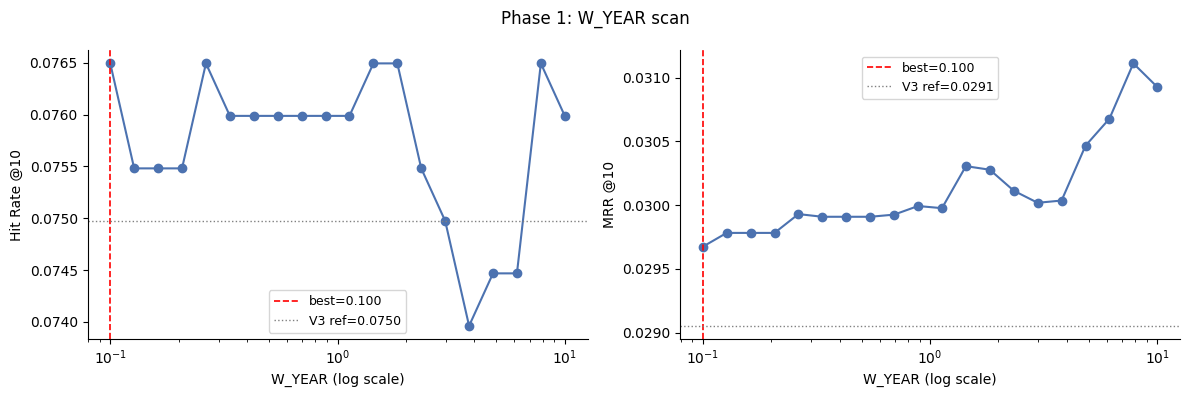

Saved: tune_year_phase1.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Phase 1: W_YEAR scan', fontsize=12)

for ax, metric, label in zip(
    axes,
    ['hit_rate', 'mrr'],
    [f'Hit Rate @{N_RESULTS}', f'MRR @{N_RESULTS}']
):
    ax.plot(p1_df['W_YEAR'], p1_df[metric], 'o-', color='#4C72B0', linewidth=1.5)
    ax.axvline(p1_best['W_YEAR'], color='red', linestyle='--', linewidth=1.2,
               label=f'best={p1_best["W_YEAR"]:.3f}')
    ax.axhline(v3_ref[metric], color='grey', linestyle=':', linewidth=1,
               label=f'V3 ref={v3_ref[metric]:.4f}')
    ax.set_xlabel('W_YEAR (log scale)')
    ax.set_ylabel(label)
    ax.set_xscale('log')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tune_year_phase1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tune_year_phase1.png')

In [9]:
# ── Phase 2: 10-point fine grid centred on Phase 1 best ──────────────────
# ±50% in log space around the best Phase 1 value
best_year = float(p1_best['W_YEAR'])
PHASE2_POINTS = np.exp(
    np.linspace(np.log(best_year * 0.5), np.log(best_year * 2.0), 10)
).tolist()

p2_results = []
print(f'Phase 2 fine grid: {len(PHASE2_POINTS)} points  '
      f'W_YEAR range [{best_year*0.5:.3f}, {best_year*2.0:.3f}]')
t0 = time.time()

for i, w_year in enumerate(PHASE2_POINTS, 1):
    scores = evaluate_weights({**FIXED, 'W_YEAR': w_year})
    p2_results.append({'W_YEAR': w_year, **scores})
    print(f'  W_YEAR={w_year:>6.3f}  hit={scores["hit_rate"]:.4f}  '
          f'mrr={scores["mrr"]:.4f}  ({time.time()-t0:.0f}s)')

p2_df   = pd.DataFrame(p2_results)
p2_best = p2_df.loc[p2_df['hit_rate'].idxmax()]
W_YEAR_FINAL = float(p2_best['W_YEAR'])

print(f'\nPhase 2 best: W_YEAR={W_YEAR_FINAL:.4f}  hit={p2_best["hit_rate"]:.4f}')

Phase 2 fine grid: 10 points  W_YEAR range [0.050, 0.200]
  W_YEAR= 0.050  hit=0.0755  mrr=0.0293  (115s)
  W_YEAR= 0.058  hit=0.0760  mrr=0.0294  (239s)
  W_YEAR= 0.068  hit=0.0755  mrr=0.0294  (391s)
  W_YEAR= 0.079  hit=0.0755  mrr=0.0295  (513s)
  W_YEAR= 0.093  hit=0.0760  mrr=0.0296  (656s)
  W_YEAR= 0.108  hit=0.0760  mrr=0.0296  (806s)
  W_YEAR= 0.126  hit=0.0765  mrr=0.0299  (945s)
  W_YEAR= 0.147  hit=0.0755  mrr=0.0298  (1057s)
  W_YEAR= 0.171  hit=0.0755  mrr=0.0298  (1176s)
  W_YEAR= 0.200  hit=0.0755  mrr=0.0298  (1316s)

Phase 2 best: W_YEAR=0.1260  hit=0.0765


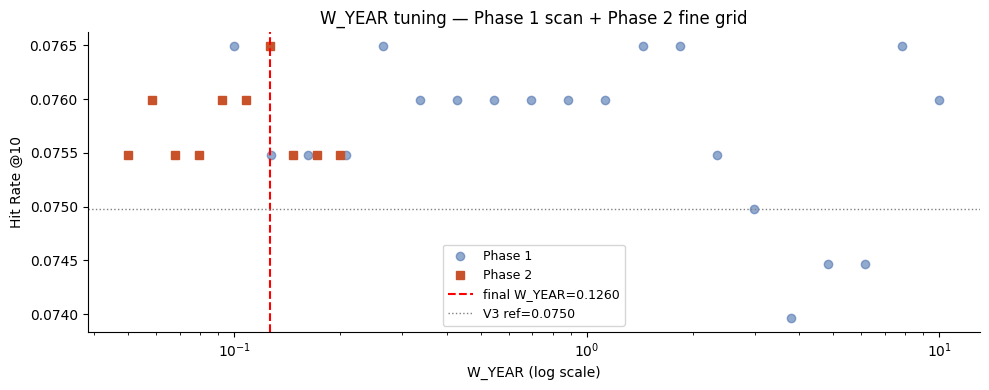

In [10]:
# Combined Phase 1 + Phase 2 plot
all_df = pd.concat([p1_df, p2_df]).sort_values('W_YEAR')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(p1_df['W_YEAR'],  p1_df['hit_rate'],  'o', color='#4C72B0',
        alpha=0.6, label='Phase 1')
ax.plot(p2_df['W_YEAR'],  p2_df['hit_rate'],  's', color='#C8522A',
        label='Phase 2')
ax.axvline(W_YEAR_FINAL, color='red', linestyle='--', linewidth=1.5,
           label=f'final W_YEAR={W_YEAR_FINAL:.4f}')
ax.axhline(v3_ref['hit_rate'], color='grey', linestyle=':', linewidth=1,
           label=f'V3 ref={v3_ref["hit_rate"]:.4f}')
ax.set_xlabel('W_YEAR (log scale)')
ax.set_ylabel(f'Hit Rate @{N_RESULTS}')
ax.set_title('W_YEAR tuning — Phase 1 scan + Phase 2 fine grid')
ax.set_xscale('log')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tune_year_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
v4_final = evaluate_weights({**FIXED, 'W_YEAR': W_YEAR_FINAL})

print('=== Final comparison ===')
print(f'{"Model":<25} {"Hit Rate":>10} {"Precision":>10} {"MRR":>8}')
print('-' * 57)
print(f'{"V3 (W_YEAR=0)":<25} {v3_ref["hit_rate"]:>10.4f} '
      f'{v3_ref["precision"]:>10.4f} {v3_ref["mrr"]:>8.4f}')
print(f'{"V4 tuned":<25} {v4_final["hit_rate"]:>10.4f} '
      f'{v4_final["precision"]:>10.4f} {v4_final["mrr"]:>8.4f}')
print(f'  W_YEAR = {W_YEAR_FINAL:.4f}')
delta = v4_final['hit_rate'] - v3_ref['hit_rate']
print(f'  Δ hit rate = {delta:+.4f}  ({delta/v3_ref["hit_rate"]*100:+.1f}%)')

=== Final comparison ===
Model                       Hit Rate  Precision      MRR
---------------------------------------------------------
V3 (W_YEAR=0)                 0.0750     0.0085   0.0291
V4 tuned                      0.0765     0.0087   0.0299
  W_YEAR = 0.1260
  Δ hit rate = +0.0015  (+2.0%)


In [12]:
best_weights['v4'] = {**FIXED, 'W_YEAR': W_YEAR_FINAL}

with open(f'{DATA_DIR}/best_weights.json', 'w') as f:
    json.dump(best_weights, f, indent=2)

print(f'best_weights.json updated with V4 weights.')
print(json.dumps(best_weights['v4'], indent=2))
print()
print('Next: rerun knn-v4.ipynb with W_YEAR set to the value above,')
print('or update the W_YEAR constant and rerun from the assemble cell.')

best_weights.json updated with V4 weights.
{
  "W_TAGS": 1.0,
  "W_LABELS": 0.32472055144502865,
  "W_TYPES": 3.5067764992972172,
  "W_RATINGS": 0.1,
  "W_COUNTRY": 1.0,
  "W_TRACK_STATS": 0.25,
  "W_ROLE_FAMILY": 0.05,
  "W_INSTRUMENT": 0.03,
  "W_CONTRIB_CNT": 0.0,
  "W_YEAR": 0.12599210498948737
}

Next: rerun knn-v4.ipynb with W_YEAR set to the value above,
or update the W_YEAR constant and rerun from the assemble cell.


In [22]:
def get_recommendations(album_id, n, model, X, album_ids_annotated, album_id_to_row, lookup_index):
    """Return list of recommended album_ids (same-artist already excluded)."""
    if album_id not in album_id_to_row:
        return None

    # Get seed artist for exclusion (optional — keeps eval consistent with app)
    try:
        input_artist = mb_lookup.loc[
            mb_lookup['album_id'] == album_id, 'artist_name'
        ].iloc[0]
    except IndexError:
        input_artist = None

    row = album_id_to_row[album_id]
    distances, indices = model.kneighbors(X[row], n_neighbors=n * 5)

    results = []
    for idx, dist in zip(indices[0], distances[0]):
        aid = album_ids_annotated[idx]
        if aid == album_id:
            continue
        if input_artist:
            cand_artist = mb_lookup.loc[
                mb_lookup['album_id'] == aid, 'artist_name'
            ]
            if not cand_artist.empty and cand_artist.iloc[0] == input_artist:
                continue
        results.append(aid)
        if len(results) == n:
            break
    return results


def evaluate_model(model, X, album_ids_annotated, album_id_to_row, ground_truth, n=10):
    """
    Compute Hit Rate @n, Precision @n, and MRR @n
    for all seed albums that exist in the model's index.
    """
    hits, precisions, reciprocal_ranks = [], [], []
    skipped = 0

    for seed_id, known_similar in ground_truth.items():
        recs = get_recommendations(
            seed_id, n, model, X, album_ids_annotated, album_id_to_row, mb_index
        )
        if recs is None:
            skipped += 1
            continue

        rec_set = set(recs)
        overlap = rec_set & known_similar

        hits.append(1 if overlap else 0)
        precisions.append(len(overlap) / n)

        # Reciprocal rank: position of first hit (1-indexed)
        rr = 0.0
        for rank, aid in enumerate(recs, start=1):
            if aid in known_similar:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    evaluated = len(hits)
    return {
        'evaluated':    evaluated,
        'skipped':      skipped,
        'hit_rate':     np.mean(hits)        if hits else 0.0,
        'precision':    np.mean(precisions)  if precisions else 0.0,
        'mrr':          np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0,
    }

In [24]:
# ── Rerun V4 with tuned W_YEAR ─────────────────────────────────────────────
import json
import numpy as np
import joblib
from scipy.sparse import hstack, load_npz
from scipy.sparse import save_npz
from numpy.linalg import norm
from sklearn.neighbors import NearestNeighbors

# ── Load weights ────────────────────────────────────────────────────────────
with open(f'{DATA_DIR}/best_weights.json') as f:
    best_weights = json.load(f)

v4 = best_weights['v4']
W_TAGS        = v4['W_TAGS']
W_LABELS      = v4['W_LABELS']
W_TYPES       = v4['W_TYPES']
W_RATINGS     = v4['W_RATINGS']
W_COUNTRY     = v4['W_COUNTRY']
W_TRACK_STATS = v4['W_TRACK_STATS']
W_ROLE_FAMILY = v4['W_ROLE_FAMILY']
W_INSTRUMENT  = v4['W_INSTRUMENT']
W_YEAR_TUNED  = v4['W_YEAR']

print('Weights loaded:')
for k, val in v4.items():
    print(f'  {k:<20} {val:.6f}')

# ── Load feature matrices ────────────────────────────────────────────────────
X_tags        = load_npz(f'{FEATURES_DIR}/album_tags_matrix.npz')
X_labels      = load_npz(f'{FEATURES_DIR}/album_labels_matrix.npz')
X_types       = load_npz(f'{FEATURES_DIR}/album_types_matrix.npz')
X_ratings     = load_npz(f'{FEATURES_DIR}/album_ratings_matrix.npz')
X_country     = load_npz(f'{FEATURES_DIR}/album_country_matrix.npz')
X_track_stats = load_npz(f'{FEATURES_DIR}/album_track_stats_matrix.npz')
X_role_family = load_npz(f'{FEATURES_DIR}/album_role_family_matrix.npz')
X_instrument  = load_npz(f'{FEATURES_DIR}/album_instrument_matrix.npz')
X_year        = load_npz(f'{FEATURES_DIR}/album_year_matrix.npz')

# ── Load ids + rebuild has_features from current matrix ─────────────────────
ids_ann = np.load(f'{DATA_DIR}/model_v4/album_ids_annotated_v4.npy')

# Rebuild has_features: rows where at least one feature block is non-zero
X_all_check = hstack([X_tags, X_labels, X_types, X_ratings, X_country,
                       X_track_stats, X_role_family, X_instrument, X_year],
                      format='csr')
has_features = np.array(X_all_check.sum(axis=1)).ravel() > 0

print(f'Total albums      : {X_all_check.shape[0]:,}')
print(f'With features     : {has_features.sum():,}')

# ── Assemble + normalise ─────────────────────────────────────────────────────
blocks_v4_tuned = [
    W_TAGS        * X_tags,
    W_LABELS      * X_labels,
    W_TYPES       * X_types,
    W_RATINGS     * X_ratings,
    W_COUNTRY     * X_country,
    W_TRACK_STATS * X_track_stats,
    W_ROLE_FAMILY * X_role_family,
    W_INSTRUMENT  * X_instrument,
    W_YEAR_TUNED  * X_year,
]

# ── Assemble + normalise (sparse, no .toarray()) ─────────────────────────────
X_v4_tuned = hstack(blocks_v4_tuned, format='csr')[has_features]

# Sparse row-wise norm
row_norms = np.sqrt(np.array(X_v4_tuned.power(2).sum(axis=1)).ravel())
row_norms[row_norms == 0] = 1
# Divide each row in-place via a diagonal matrix
from scipy.sparse import diags
X_norm_v4_tuned = diags(1.0 / row_norms) @ X_v4_tuned

model_v4_tuned = NearestNeighbors(n_neighbors=11, metric='cosine', algorithm='brute', n_jobs=-1)
model_v4_tuned.fit(X_norm_v4_tuned)

# # ── Evaluate ─────────────────────────────────────────────────────────────────
# hr, prec, mrr = evaluate_model(model_v4_tuned, X_norm_v4_tuned, ids_ann, annotations)
# print(f'\n=== V4 rerun (W_YEAR={W_YEAR_TUNED:.4f}) ===')
# print(f'  Hit Rate : {hr:.4f}')
# print(f'  Precision: {prec:.4f}')
# print(f'  MRR      : {mrr:.4f}')

# try:
#     _hr_v3, _mrr_v3 = hr_v3, mrr_v3
# except NameError:
#     _hr_v3, _mrr_v3 = 0.0750, 0.0291

# print(f'\n  Δ vs V3 (W_YEAR=0):')
# print(f'    Hit Rate : {hr - _hr_v3:+.4f}  ({(hr - _hr_v3)/_hr_v3*100:+.1f}%)')
# print(f'    MRR      : {mrr - _mrr_v3:+.4f}')

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(model_v4_tuned, f'{DATA_DIR}/model_v4/knn_model_v4.joblib')
save_npz(f'{DATA_DIR}/model_v4/X_knn_norm_v4.npz', X_norm_v4_tuned)
print('\nSaved updated model_v4 artefacts.')

Weights loaded:
  W_TAGS               1.000000
  W_LABELS             0.324721
  W_TYPES              3.506776
  W_RATINGS            0.100000
  W_COUNTRY            1.000000
  W_TRACK_STATS        0.250000
  W_ROLE_FAMILY        0.050000
  W_INSTRUMENT         0.030000
  W_CONTRIB_CNT        0.000000
  W_YEAR               0.125992
Total albums      : 1,008,102
With features     : 1,000,406

Saved updated model_v4 artefacts.
